# Nigerian Pidgin Sentiment Analyzer
**3MTT AI/ML Project — Oche Abel**

**Problem:** Businesses get customer feedback in Nigerian Pidgin/English that generic sentiment tools misread.

**MVP:** A text classifier that labels feedback as **positive**, **negative**, or **neutral**, with a confidence/accuracy report.

**Dataset:** `pidgin_sentiment_v5_refined2.csv` — 11,491 labeled examples (see EDA below for a breakdown of what's in it).



In [1]:
# --- Setup ---
!pip install -q scikit-learn pandas matplotlib seaborn joblib

import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load the data


In [2]:
DATA_PATH = "pidgin_sentiment_v5_refined2.csv"

# Uncomment to upload interactively in Colab:
# from google.colab import files
# uploaded = files.upload()
# DATA_PATH = list(uploaded.keys())[0]

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["text", "label"]).reset_index(drop=True)
print("Shape:", df.shape)
df.head()

Shape: (11491, 2)


,text,label
0,"Sha, the appointment waste my time.",negative
1,god help u if ure pregnant they be like when u...,negative
2,"I think, the cart price change small but I fit...",neutral
3,"My guy, the result need verification because I...",neutral
4,you still dey wait for my failureyou go wait f...,positive


## 2. Exploratory data check



Label distribution:
label
negative    4859
positive    4388
neutral     2244
Name: count, dtype: int64

label
negative    0.423
positive    0.382
neutral     0.195
Name: proportion, dtype: float64


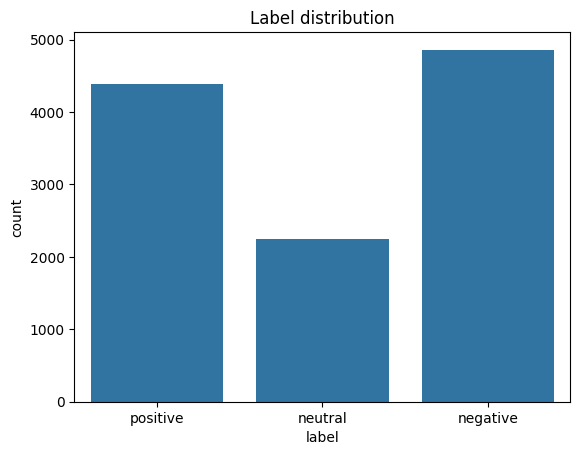

In [3]:
print("Label distribution:")
print(df["label"].value_counts())
print()
print(df["label"].value_counts(normalize=True).round(3))

sns.countplot(data=df, x="label", order=["positive", "neutral", "negative"])
plt.title("Label distribution")
plt.show()

In [4]:
openers = ("Sha,", "My guy,", "I think,", "Honestly,", "Meanwhile,", "For real,",
           "Omo,", "Chai,", "Abeg,", "No lie,", "Today,", "Yesterday,",
           "This morning,", "See ehn,", "Na true say,")
templated_mask = df["text"].str.startswith(openers)
print(f"Templated / on-topic rows: {templated_mask.sum()} ({templated_mask.mean()*100:.1f}%)")
print(f"Organic / general rows:    {(~templated_mask).sum()} ({(~templated_mask).mean()*100:.1f}%)")

df["text_len_words"] = df["text"].str.split().str.len()
df["text_len_words"].describe()

Templated / on-topic rows: 4474 (38.9%)
Organic / general rows:    7017 (61.1%)


,text_len_words
count,11491.000000
mean,14.984858
std,8.217217
min,3.000000
25%,9.000000
50%,13.000000
75%,19.000000
max,40.000000


## 3. Light text cleaning

I do minimal cleaning only — Pidgin sentiment signal often lives in spelling, spacing, and repeated letters (e.g. "sweeeet"), so we avoid aggressive normalization that would strip that out. We just:
- lowercase
- strip URLs / @mentions / stray non-printable characters
- collapse repeated whitespace

In [5]:
def clean_text(t):
    t = str(t)
    t = t.lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = re.sub(r"[\u200d\ufe0f]", " ", t)  # stray emoji/zero-width joiner artifacts
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].sample(5, random_state=RANDOM_STATE)

,text,clean_text
1516,una see the sequence dem dey share am,una see the sequence dem dey share am
1393,"Yesterday, the ride send notification.","yesterday, the ride send notification."
10561,"Sha, the bus de available now and I fit use am...","sha, the bus de available now and i fit use am..."
9168,"Honestly, the passport office de available now...","honestly, the passport office de available now..."
647,"Yesterday, the lecture customer care help me q...","yesterday, the lecture customer care help me q..."


## 4. Train / test split

Stratified split so all three classes keep their proportions in both sets — important since `neutral` is under-represented (~20%).

In [6]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train size:", len(X_train), " Test size:", len(X_test))
print(y_train.value_counts(normalize=True).round(3))

Train size: 9192  Test size: 2299
label
negative    0.423
positive    0.382
neutral     0.195
Name: proportion, dtype: float64


## 5. Vectorize + train

TF-IDF over word unigrams+bigrams, plus character n-grams to help with Pidgin spelling variation (e.g. "sabi", "wahala", "abeg" spelled differently across posts). i compare two classifiers quickly and keep the better one.

In [7]:
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", C=5, random_state=RANDOM_STATE
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced", C=1, random_state=RANDOM_STATE
    ),
}

results = {}
for name, clf in models.items():
    pipe = Pipeline([("tfidf", word_vectorizer), ("clf", clf)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results[name] = {"pipeline": pipe, "accuracy": acc, "macro_f1": f1, "preds": preds}
    print(f"{name}: accuracy={acc:.3f}  macro_f1={f1:.3f}")

Logistic Regression: accuracy=0.781  macro_f1=0.792
Linear SVM: accuracy=0.770  macro_f1=0.781


In [8]:
best_name = max(results, key=lambda k: results[k]["macro_f1"])
best_pipe = results[best_name]["pipeline"]
best_preds = results[best_name]["preds"]
print("Best model:", best_name)

Best model: Logistic Regression


## 6. Evaluation

In [9]:
print(classification_report(y_test, best_preds, digits=3))

              precision    recall  f1-score   support

    negative      0.748     0.811     0.778       972
     neutral      0.918     0.777     0.842       449
    positive      0.761     0.749     0.755       878

    accuracy                          0.781      2299
   macro avg      0.809     0.779     0.792      2299
weighted avg      0.786     0.781     0.782      2299



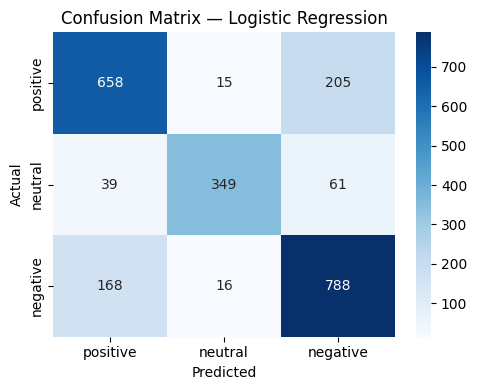

In [10]:
labels_order = ["positive", "neutral", "negative"]
cm = confusion_matrix(y_test, best_preds, labels=labels_order)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 7. Error analysis

A quick look at misclassified examples — useful for the README / demo talking points.

In [11]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": best_preds,
})
errors = error_df[error_df["actual"] != error_df["predicted"]]
print(f"{len(errors)} / {len(error_df)} misclassified ({len(errors)/len(error_df)*100:.1f}%)")
errors.sample(min(10, len(errors)), random_state=RANDOM_STATE)

504 / 2299 misclassified (21.9%)


,text,actual,predicted
820,my bank transfer failed again.,negative,positive
1265,ah the idea is they are also supposed to campa...,positive,negative
2239,me my guy abeg take earphone upcoming artist t...,negative,positive
363,everytime i wake up na your face i wana see wi...,positive,negative
1384,no dey slander my man pulliz,negative,positive
377,bosse pain them girlcott in da mudd,positive,negative
2164,ph babes don chop am,neutral,positive
657,lol i left all to follow him bro na only food ...,positive,negative
2141,who is doing who i don mumu myself before sha ...,positive,negative
2270,everyone keeps talking bout paternity test you...,negative,positive


## 8. Save the model

Saves the full pipeline (TF-IDF + classifier) as one file — no need to save the vectorizer separately.

In [12]:
joblib.dump(best_pipe, "sentiment_model.joblib")
print("Saved sentiment_model.joblib")

Saved sentiment_model.joblib


## 9. Inference demo

Try it on your own sentences.

In [13]:
def predict_sentiment(text, pipe=best_pipe):
    cleaned = clean_text(text)
    pred = pipe.predict([cleaned])[0]
    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        proba = pipe.predict_proba([cleaned])[0]
        conf = dict(zip(pipe.classes_, proba.round(3)))
        return pred, conf
    else:
        # LinearSVC has no predict_proba by default
        score = pipe.decision_function([cleaned])[0]
        return pred, dict(zip(pipe.classes_, score.round(3)))

demo_examples = [
    "This network dey epileptic, e dey enter and comot anyhow.",
    "The delivery guy come sharp sharp, everything correct.",
    "The price for this product na five thousand naira.",
    "Wahala full ground, transaction fail three times today.",
    "Customer care attend to me fast, dem sabi their work.",
]

for text in demo_examples:
    pred, scores = predict_sentiment(text)
    print(f"[{pred.upper():8}] {text}")
    print(f"           scores: {scores}\n")

[NEGATIVE] This network dey epileptic, e dey enter and comot anyhow.
           scores: {'negative': np.float64(0.691), 'neutral': np.float64(0.057), 'positive': np.float64(0.252)}

[POSITIVE] The delivery guy come sharp sharp, everything correct.
           scores: {'negative': np.float64(0.007), 'neutral': np.float64(0.004), 'positive': np.float64(0.989)}

[POSITIVE] The price for this product na five thousand naira.
           scores: {'negative': np.float64(0.176), 'neutral': np.float64(0.24), 'positive': np.float64(0.584)}

[NEGATIVE] Wahala full ground, transaction fail three times today.
           scores: {'negative': np.float64(0.698), 'neutral': np.float64(0.116), 'positive': np.float64(0.186)}

[POSITIVE] Customer care attend to me fast, dem sabi their work.
           scores: {'negative': np.float64(0.262), 'neutral': np.float64(0.05), 'positive': np.float64(0.688)}



In [14]:
# Try your own text here
predict_sentiment("Abeg this app too slow, I don wait tire")

('negative',
 {'negative': np.float64(0.991),
  'neutral': np.float64(0.004),
  'positive': np.float64(0.005)})

## Notes / limitations
- The dataset blends on-topic business-feedback style text (~39%) with general Pidgin social-media-style text (~61%). This gives broader vocabulary coverage but means the model isn't purely tuned to customer-feedback language.
- `neutral` is the smallest class (~20%) — watch its precision/recall specifically; it's usually the hardest class to get right in sentiment tasks.
- This is a classical ML baseline (TF-IDF + linear model), matching the MVP scope. A transformer-based model (e.g. fine-tuned AfriBERTa/XLM-R) would likely do better on the noisier/organic text but is out of scope for the MVP.